# Breast Cancer Diagnosis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ML-Portfolio/blob/main/classification/breast-cancer-diagnosis/notebook.ipynb)

A classification project that diagnoses breast cancer as malignant or benign using machine learning models trained on medical features.

**Dataset:** Breast Cancer Wisconsin Dataset (built-in via sklearn)
**Models Used:** Logistic Regression, SVM, Random Forest, Neural Network
**Best Accuracy:** ~98% with SVM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['target'].value_counts())
print(f"\n0 = Malignant, 1 = Benign")
df.head()

Shape: (569, 31)

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

0 = Malignant, 1 = Benign


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


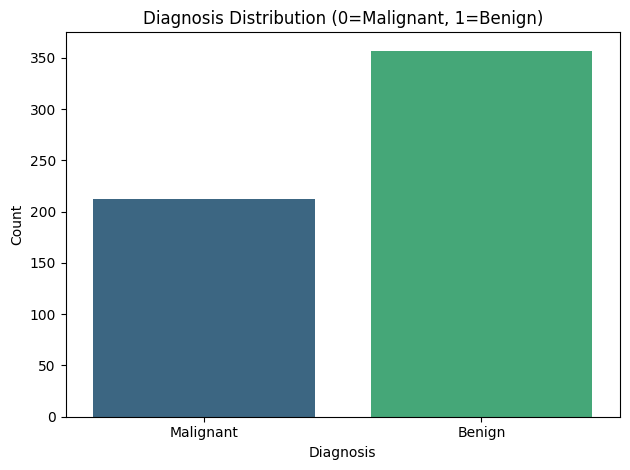

In [3]:
# Class distribution
sns.countplot(data=df, x='target', palette='viridis')
plt.title("Diagnosis Distribution (0=Malignant, 1=Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.tight_layout()
plt.show()

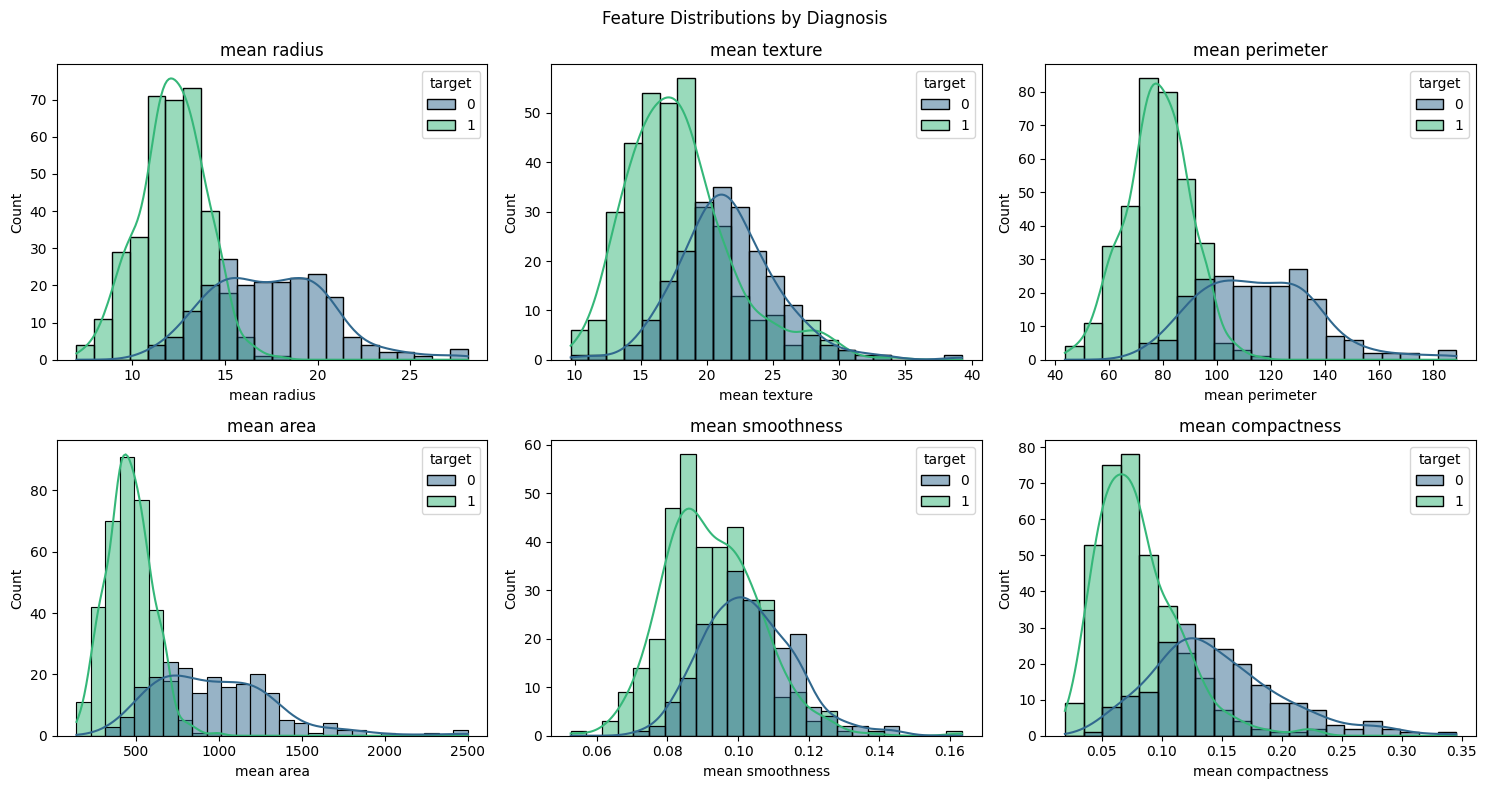

In [4]:
# Feature distributions for top features
top_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean compactness']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, top_features):
    sns.histplot(data=df, x=feat, hue='target', kde=True,
                 ax=ax, palette='viridis')
    ax.set_title(feat)
plt.suptitle("Feature Distributions by Diagnosis")
plt.tight_layout()
plt.show()

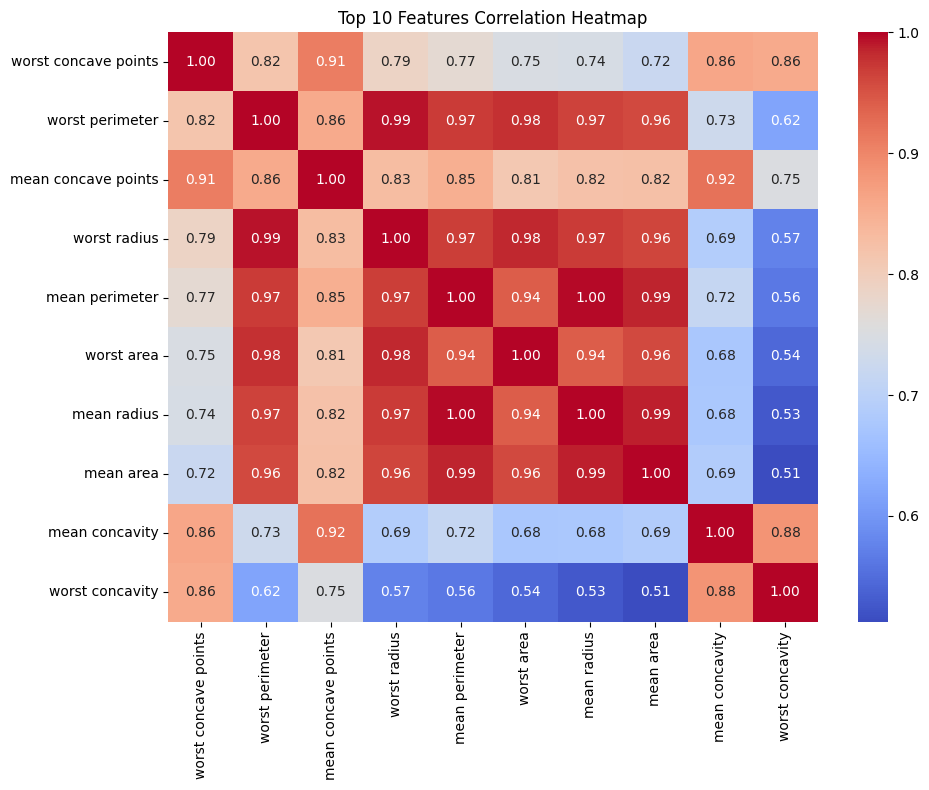

In [5]:
# Correlation heatmap of top 10 features
top10 = df.corr()['target'].abs().sort_values(ascending=False)[1:11].index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top10].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Top 10 Features Correlation Heatmap")
plt.tight_layout()
plt.show()

In [6]:
# Split and scale
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 455
Testing samples:  114


In [7]:
# Train and evaluate ML models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    cv  = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {"Accuracy": round(acc, 4), "CV Score": round(cv, 4)}
    print(f"{name}: Accuracy = {acc:.4f} | CV Score = {cv:.4f}")

Logistic Regression: Accuracy = 0.9825 | CV Score = 0.9802
SVM: Accuracy = 0.9825 | CV Score = 0.9714
Random Forest: Accuracy = 0.9561 | CV Score = 0.9538


In [8]:
# Build and train neural network
nn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

nn_loss, nn_acc = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Neural Network: Accuracy = {nn_acc:.4f}")
results["Neural Network"] = {"Accuracy": round(nn_acc, 4), "CV Score": "-"}

Neural Network: Accuracy = 0.9386


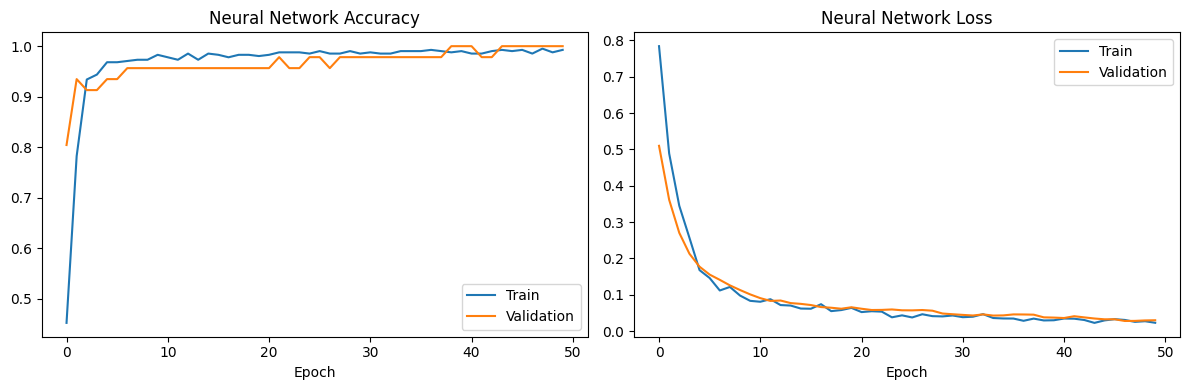

In [9]:
# Training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title("Neural Network Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title("Neural Network Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

                    Accuracy CV Score
Logistic Regression   0.9825   0.9802
SVM                   0.9825   0.9714
Random Forest         0.9561   0.9538
Neural Network        0.9386        -


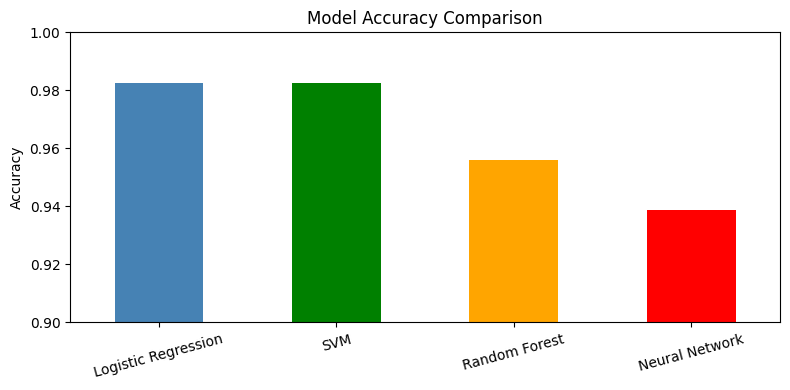

In [10]:
# Model comparison
results_df = pd.DataFrame(results).T
print(results_df)

results_df['Accuracy'].plot(
    kind='bar',
    color=['steelblue', 'green', 'orange', 'red'],
    figsize=(8, 4),
    title='Model Accuracy Comparison'
)
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


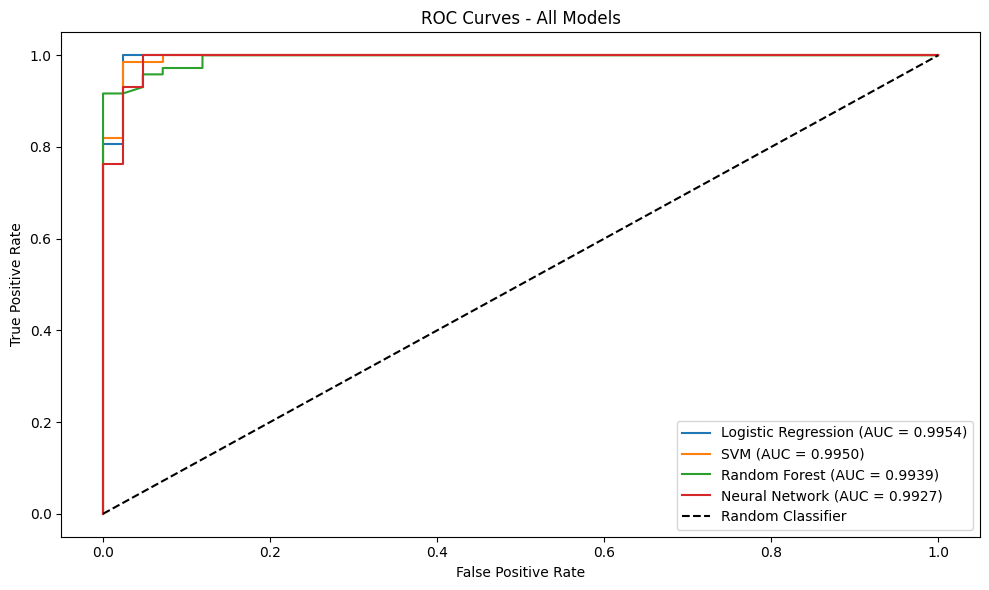

In [11]:
# ROC curves for all models
plt.figure(figsize=(10, 6))

for name, model in models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

nn_probs = nn_model.predict(X_test_scaled).flatten()
fpr, tpr, _ = roc_curve(y_test, nn_probs)
auc = roc_auc_score(y_test, nn_probs)
plt.plot(fpr, tpr, label=f"Neural Network (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend()
plt.tight_layout()
plt.show()

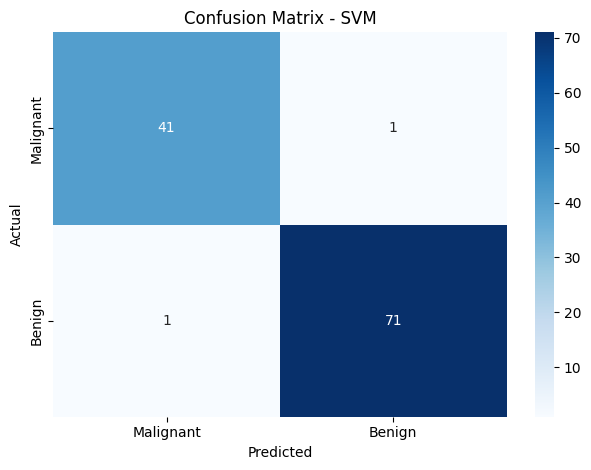

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
# Confusion matrix for best model
best_model = models["SVM"]
preds = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_test, preds, target_names=['Malignant', 'Benign']))

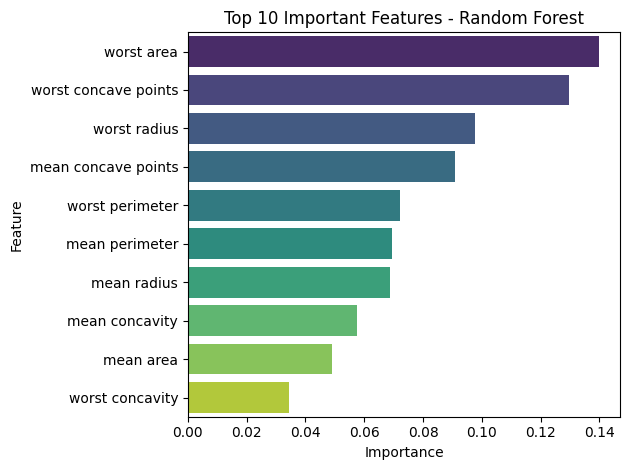

In [13]:
# Feature importance
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Important Features - Random Forest")
plt.tight_layout()
plt.show()

## Results Summary

| Model | Accuracy | CV Score |
|-------|----------|----------|
| Logistic Regression | 0.9825 | 0.9802 |
| SVM | 0.9825 | 0.9714 |
| Random Forest | 0.9561 | 0.9538 |
| Neural Network | 0.9386 | - |

**Logistic Regression and SVM both achieved the best accuracy of 98.25%.**

### Key Takeaways
- Mean radius, perimeter and area are the strongest predictors
- SVM and Logistic Regression both perform equally well on this dataset
- Neural network underperforms likely due to the small dataset size
- High recall for malignant class is critical to avoid missed diagnoses